## Binary Logistic Regression

Here in activation we use softmax function and in loss function we use cross entropy loss function.

# Sigmoid Activation

In [1]:
import numpy as np

In [2]:
class sigmiod_activation:
  def __init__(self):
    pass
  def forward(self,input):
    self.inputs=input
    self.output=1/(1+np.exp(-input))
  def backward(self,dvalues):
    self.dinputs=dvalues*(1-self.output)*self.output  

# Binary cross entropy loss function

In [3]:
class binary_cross_entropy_loss:
  def forward(self,y_pred,y_true):
    y_pred_clipped=np.clip(y_pred,1e-7,1-1e-7)# to avoid log(0) error
    sample_loss=-(y_true*np.log(y_pred_clipped)+(1-y_true)*np.log(1-y_pred_clipped))
    sample_loss=np.mean(sample_loss,axis=-1)
    return sample_loss
  def backward(self,dvalues,y_true):
    samples=len(dvalues)
    num_output=len(dvalues[0])
    clipped_dvalues=np.clip(dvalues,1e-7,1-1e-7)
    self.inputs=-((y_true/clipped_dvalues)-((1-y_true)/(1-clipped_dvalues)))/num_output
    self.inputs=self.inputs/samples

# Implementing Binary Logistic Regression and Binary Cross-Entropy Loss

In [4]:
from nnfs.datasets import spiral_data
import numpy as np
import nnfs
nnfs.init()
from My_NN.Layer_Dense import  Layer_Dense
from My_NN.activation import  ReLU
from My_NN.activation import  sigmiod_activation
from My_NN.Loss import  binary_cross_entropy_loss,Loss
from My_NN.optimizer import Adam_Optimizer
from My_NN.dropout import Layer_dropout

In [5]:
x, y = spiral_data(samples=100, classes=2)
#reshape y to be a column vector
y=y.reshape(-1,1)
dense1 = Layer_Dense(2, 64,weight_regularizer_l2=5e-4,bias_regularizer_l2=5e-4)
activation1 = ReLU()
dense2 = Layer_Dense(64,128,weight_regularizer_l2=5e-4,bias_regularizer_l2=5e-4)
activation2 = ReLU()
dense3 = Layer_Dense(128,64,weight_regularizer_l2=5e-4,bias_regularizer_l2=5e-4)
activation3 = ReLU()
dropout1 = Layer_dropout(0.1)
dropout2 = Layer_dropout(0.1)
dropout3 = Layer_dropout(0.1)
dense4 = Layer_Dense(64,1,weight_regularizer_l2=5e-4,bias_regularizer_l2=5e-4)
activation4=sigmiod_activation()
loss_function=binary_cross_entropy_loss()
loss_regul=Loss()
optimizer = Adam_Optimizer()

In [6]:
x.shape, y.shape
dense1

In [7]:
#randomly five sample see
for i in range(5):
  ind=np.random.randint(0,len(x))
  print(f'sample:{x[ind]}, label:{y[ind]}')
#count values in each class
classes, counts=np.unique(y,return_counts=True)
print(f'\nclass values:{classes}, counts:{counts}')  

sample:[-0.11844549 -0.02574967], label:[1]
sample:[ 0.41358972 -0.27187964], label:[1]
sample:[ 0.969427   -0.24538004], label:[1]
sample:[-0.6633561   0.29813468], label:[1]
sample:[-0.07763252  0.1644112 ], label:[1]

class values:[0 1], counts:[100 100]


In [8]:
from torch import dropout

acurracys=[]
losses=[]
epochs=1001
for epoch in range(epochs):
  
  dense1.forward(x)
  activation1.forward(dense1.output)
  dropout1.forward(activation1.output)
  
  dense2.forward(dropout1.output)
  activation2.forward(dense2.output)
  dropout2.forward(activation2.output)
  
  dense3.forward(dropout2.output)
  activation3.forward(dense3.output)
  dropout3.forward(activation3.output)

  dense4.forward(dropout3.output)
  activation4.forward(dense4.output)
  
  data_loss=loss_function.calculate(activation4.output,y)
  
  reg_loss = (
    loss_regul.regularization_loss(dense1) +
    loss_regul.regularization_loss(dense2) +
    loss_regul.regularization_loss(dense3) +
    loss_regul.regularization_loss(dense4)
)
  loss=data_loss+reg_loss
  
  predictions=(activation4.output>0.5)*1
  accuracy=np.mean(predictions==y)
  if epoch%10==0:
    print(f'epoch:{epoch}, loss:{loss}, accuracy:{accuracy}')
  
  losses.append(loss)
  acurracys.append(accuracy)
    
  loss_function.backward(activation4.output, y)
  activation4.backward(loss_function.dinputs)

  dense4.backward(activation4.dinputs)

  dropout3.backward(dense4.dinputs)
  activation3.backward(dropout3.dinputs)
  dense3.backward(activation3.dinputs)

  dropout2.backward(dense3.dinputs)
  activation2.backward(dropout2.dinputs)
  dense2.backward(activation2.dinputs)

  dropout1.backward(dense2.dinputs)
  activation1.backward(dropout1.dinputs)
  dense1.backward(activation1.dinputs)
  
  optimizer.update_params(dense1)
  optimizer.update_params(dense2)
  optimizer.update_params(dense3)
  optimizer.update_params(dense4)

epoch:0, loss:0.693956616397947, accuracy:0.43
epoch:10, loss:0.6932747570481477, accuracy:0.5
epoch:20, loss:0.6935664284127229, accuracy:0.605
epoch:30, loss:0.6936164697892736, accuracy:0.625
epoch:40, loss:0.6904019182848969, accuracy:0.63
epoch:50, loss:0.6828803699102427, accuracy:0.62
epoch:60, loss:0.6810048070257763, accuracy:0.635
epoch:70, loss:0.6781384928922635, accuracy:0.61
epoch:80, loss:0.6825187020045705, accuracy:0.64
epoch:90, loss:0.6808308566680644, accuracy:0.63
epoch:100, loss:0.6755728755691088, accuracy:0.63
epoch:110, loss:0.6803954943506978, accuracy:0.62
epoch:120, loss:0.6766237926683388, accuracy:0.665
epoch:130, loss:0.6751350365877151, accuracy:0.645
epoch:140, loss:0.67824229068961, accuracy:0.65
epoch:150, loss:0.6775910217734054, accuracy:0.645
epoch:160, loss:0.6719725391445681, accuracy:0.65
epoch:170, loss:0.6720981222428382, accuracy:0.65
epoch:180, loss:0.6705344359977171, accuracy:0.655
epoch:190, loss:0.6765310666225851, accuracy:0.665
epoch:2

# acuracy and loss history

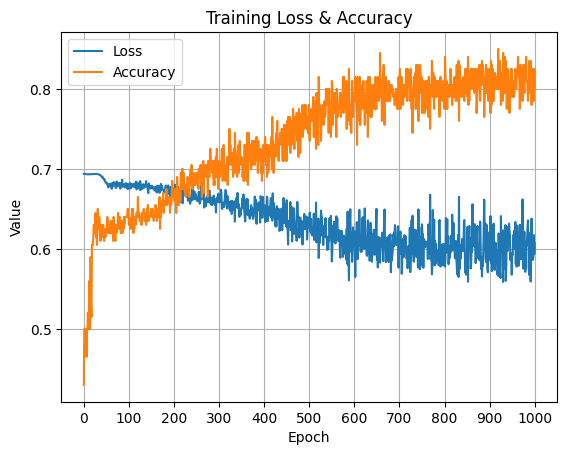

In [18]:
import matplotlib.pyplot as plt

epochs_range = range(len(losses))

plt.figure()

# Plot Loss
plt.plot(epochs_range, losses, label="Loss")

# Plot Accuracy
plt.plot(epochs_range, acurracys, label="Accuracy")
plt.xticks(np.arange(0, len(losses), 100)) 
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss & Accuracy")
plt.legend()
plt.grid()

plt.show()

# Testing

In [10]:

for i in range(5):
  x_text, y_test = spiral_data(samples=100, classes=2)
  dense1.forward(x)
  activation1.forward(dense1.output)
  dropout1.forward(activation1.output)
  
  dense2.forward(dropout1.output)
  activation2.forward(dense2.output)
  dropout2.forward(activation2.output)
  
  dense3.forward(dropout2.output)
  activation3.forward(dense3.output)
  dropout3.forward(activation3.output)

  dense4.forward(dropout3.output)
  activation4.forward(dense4.output)
  
  loss=loss_function.calculate(activation4.output,y)
  

  predictions=(activation4.output>0.5)*1
  accuracy=np.mean(predictions==y)
  if epoch%10==0:
    print(f'epoch:{epoch}, loss:{loss}, accuracy:{accuracy}')
   

epoch:1000, loss:0.40835028886795044, accuracy:0.795
epoch:1000, loss:0.3699004054069519, accuracy:0.84
epoch:1000, loss:0.3892190456390381, accuracy:0.83
epoch:1000, loss:0.4037039279937744, accuracy:0.815
epoch:1000, loss:0.3820290267467499, accuracy:0.81
